In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("insurance_fraud_data.csv")

In [4]:
df.head()

,claim_number,age_of_driver,gender,marital_status,safety_rating,annual_income,high_education,address_change,property_status,zip_code,...,vehicle_category,vehicle_price,vehicle_color,total_claim,injury_claim,policy deductible,annual premium,days open,form defects,fraud reported
0,414724,39,M,1,73,58612.8,1,0,Own,50048,...,Large,24360.59273,silver,26633.27819,5196.552552,1000,1406.91,8.641800,5,N
1,269568,33,M,1,72,35936.0,0,1,Own,50006,...,Medium,23457.35282,black,26707.46021,7957.267641,2000,1415.74,10.009761,5,Y
2,974592,31,M,1,76,84940.8,1,1,Own,15021,...,Medium,19752.42523,gray,15279.38583,3014.110884,1000,1199.44,8.264032,3,N
3,995328,53,F,1,93,73526.4,0,1,Own,85027,...,Medium,32910.34224,red,20909.27772,5671.599025,500,708.64,9.235943,4,N
4,1140480,41,M,1,87,59403.2,1,0,Own,80046,...,Medium,28570.37675,red,34493.97997,4064.569489,1000,1187.96,10.259629,2,N


In [5]:
df.shape

(12002, 29)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12002 entries, 0 to 12001
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   claim_number        12002 non-null  int64  
 1   age_of_driver       12002 non-null  int64  
 2   gender              12002 non-null  object 
 3   marital_status      12002 non-null  object 
 4   safety_rating       12002 non-null  int64  
 5   annual_income       12002 non-null  float64
 6   high_education      12002 non-null  int64  
 7   address_change      12002 non-null  int64  
 8   property_status     12002 non-null  object 
 9   zip_code            12002 non-null  int64  
 10  claim_date          12002 non-null  object 
 11  claim_day_of_week   12002 non-null  object 
 12  accident_site       12002 non-null  object 
 13  past_num_of_claims  12002 non-null  int64  
 14  witness_present     12002 non-null  object 
 15  liab_prct           12002 non-null  int64  
 16  chan

## Check missing value per column ##

In [7]:
df.isnull().sum()

claim_number          0
age_of_driver         0
gender                0
marital_status        0
safety_rating         0
annual_income         0
high_education        0
address_change        0
property_status       0
zip_code              0
claim_date            0
claim_day_of_week     0
accident_site         0
past_num_of_claims    0
witness_present       0
liab_prct             0
channel               0
police_report         0
age_of_vehicle        0
vehicle_category      0
vehicle_price         0
vehicle_color         0
total_claim           0
injury_claim          0
policy deductible     0
annual premium        0
days open             0
form defects          0
fraud reported        8
dtype: int64

## Delete missing values rows (fraud reported = 8) ##

In [8]:
df.dropna(inplace=True)

In [9]:
df.shape

(11994, 29)

## Check for duplicate rows ##

In [10]:
df.duplicated().sum()

np.int64(0)

## Check for outliers ##

In [11]:
df.describe()

,claim_number,age_of_driver,safety_rating,annual_income,high_education,address_change,zip_code,past_num_of_claims,liab_prct,police_report,vehicle_price,total_claim,policy deductible,annual premium,days open,form defects
count,1.199400e+04,11994.000000,11994.000000,11994.000000,11994.000000,11994.000000,11994.000000,11994.000000,11994.000000,11994.000000,11994.000000,11994.000000,11994.000000,11994.000000,11994.000000,11994.000000
mean,3.119281e+08,43.524596,73.699350,63660.607208,0.697932,0.576788,49750.514424,0.494664,49.777639,0.601134,22923.067048,22862.097420,1011.172253,1268.180552,8.799665,3.969985
std,1.796223e+08,12.201993,15.381656,17294.820248,0.459174,0.494089,29129.675797,0.955447,33.580748,0.489686,12103.015287,12200.404752,562.117629,231.677198,2.413267,1.987311
min,1.866240e+05,19.000000,2.000000,-1.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2261.507903,2583.428985,500.000000,433.330000,2.303305,0.000000
25%,1.561110e+08,35.000000,66.000000,56899.200000,0.000000,0.000000,20111.000000,0.000000,18.000000,0.000000,14087.969238,13831.891842,500.000000,1082.360000,8.025550,3.000000
50%,3.120975e+08,43.000000,76.000000,60899.200000,1.000000,1.000000,50027.000000,0.000000,50.000000,1.000000,20642.029325,20508.293695,1000.000000,1239.060000,9.268571,4.000000
75%,4.677212e+08,51.000000,85.000000,64699.200000,1.000000,1.000000,80036.000000,1.000000,82.000000,1.000000,29288.710273,29207.740320,1000.000000,1383.490000,10.309024,5.000000
max,6.220385e+08,278.000000,100.000000,257313.600000,1.000000,1.000000,85083.000000,6.000000,100.000000,1.000000,106991.684500,101818.964200,2000.000000,2047.590000,15.177169,13.000000


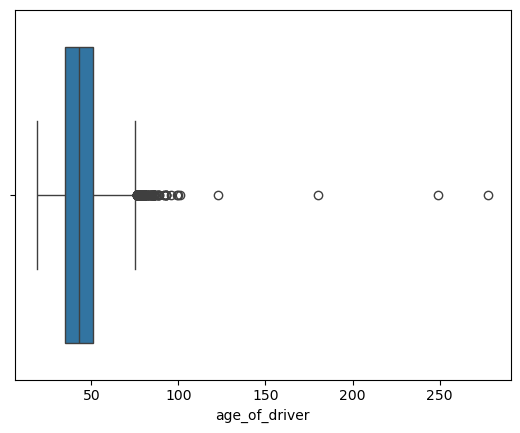

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x=df['age_of_driver'])
plt.show()

In [13]:
Q1 = df['age_of_driver'].quantile(0.25)
Q3 = df['age_of_driver'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Limit =", lower)
print("Upper Limit =", upper)

Q1 = 35.0
Q3 = 51.0
IQR = 16.0
Lower Limit = 11.0
Upper Limit = 75.0


## Delete outliers rows ##

In [14]:
df = df[(df['age_of_driver'] >= lower) & (df['age_of_driver'] <= upper)] #121 rows

In [15]:
df.shape

(11873, 29)

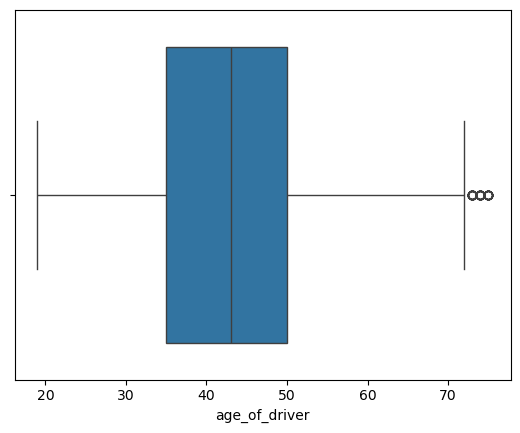

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x=df['age_of_driver'])
plt.show()

## Correct Datatypes ##

In [17]:
df.dtypes

claim_number            int64
age_of_driver           int64
gender                 object
marital_status         object
safety_rating           int64
annual_income         float64
high_education          int64
address_change          int64
property_status        object
zip_code                int64
claim_date             object
claim_day_of_week      object
accident_site          object
past_num_of_claims      int64
witness_present        object
liab_prct               int64
channel                object
police_report           int64
age_of_vehicle         object
vehicle_category       object
vehicle_price         float64
vehicle_color          object
total_claim           float64
injury_claim           object
policy deductible       int64
annual premium        float64
days open             float64
form defects            int64
fraud reported         object
dtype: object

In [18]:
print((df['claim_date'] == '*').sum())

14


In [19]:
df = df[df['claim_date'] != '*']
df.shape

(11859, 29)

In [20]:
#Change datatype of claim_date from object to datetime
df['claim_date'] = pd.to_datetime(
    df['claim_date'],
    format='mixed',
    errors='coerce'
)
print(df['claim_date'].dtype)

datetime64[ns]


## Encode Categories ##

In [21]:
df['fraud reported'] = df['fraud reported'].map({
    'N': 0,
    'Y': 1
})

In [22]:
print(df['fraud reported'].head())
print(df['fraud reported'].dtype)

0    0
1    1
2    0
3    0
4    0
Name: fraud reported, dtype: int64
int64


## Visualise the Data ##

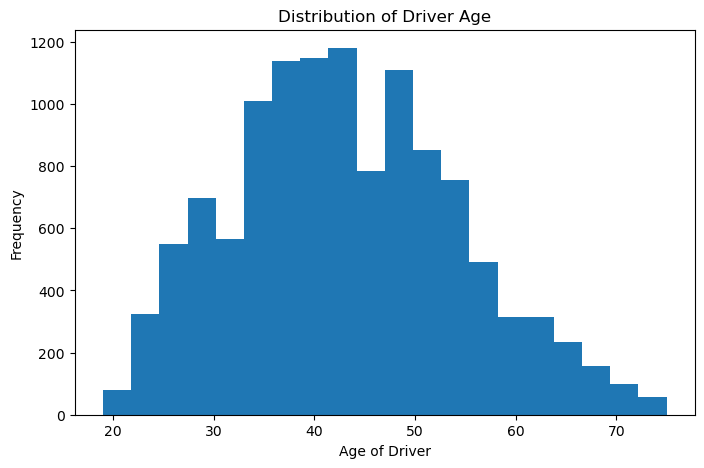

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['age_of_driver'], bins=20)

plt.title("Distribution of Driver Age")
plt.xlabel("Age of Driver")
plt.ylabel("Frequency")

plt.show()

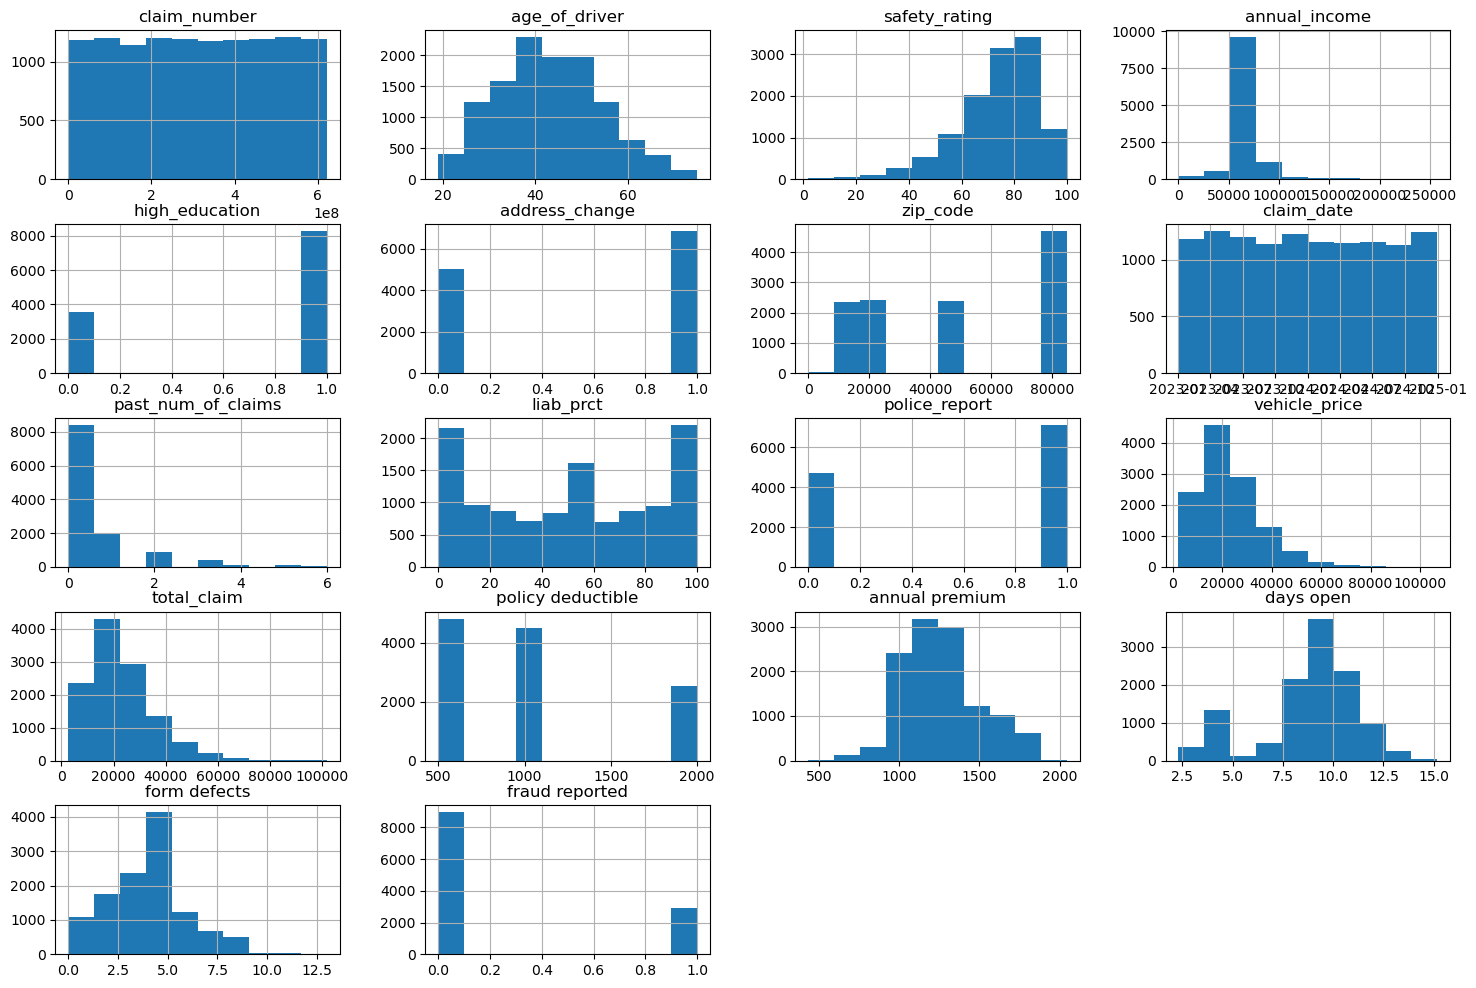

In [24]:
df.hist(figsize=(18,12)) #ALL NUMERICAL COLUMNS..
plt.show()

In [25]:
df.shape

(11859, 29)

In [26]:
# Prepare the final model-ready dataset

# Work on a copy so the preprocessing above remains unchanged
df_cleaned = df.copy()

# Convert numeric-looking columns to numeric
df_cleaned['age_of_vehicle'] = pd.to_numeric(
    df_cleaned['age_of_vehicle'],
    errors='coerce'
)

df_cleaned['injury_claim'] = pd.to_numeric(
    df_cleaned['injury_claim'],
    errors='coerce'
)

# Fill invalid/missing numeric values with the median
df_cleaned['age_of_vehicle'] = df_cleaned['age_of_vehicle'].fillna(
    df_cleaned['age_of_vehicle'].median()
)

df_cleaned['injury_claim'] = df_cleaned['injury_claim'].fillna(
    df_cleaned['injury_claim'].median()
)

# Remove any dates that could not be converted
df_cleaned = df_cleaned.dropna(subset=['claim_date']).copy()

# Extract useful numerical information from claim_date
df_cleaned['claim_year'] = df_cleaned['claim_date'].dt.year
df_cleaned['claim_month'] = df_cleaned['claim_date'].dt.month
df_cleaned['claim_day'] = df_cleaned['claim_date'].dt.day

# Remove the original datetime column
df_cleaned = df_cleaned.drop('claim_date', axis=1)

# Handle '*' in categorical columns
for col in ['marital_status', 'witness_present']:
    df_cleaned[col] = df_cleaned[col].replace('*', pd.NA)
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

# One-hot encode categorical variables
df_cleaned = pd.get_dummies(
    df_cleaned,
    columns=[
        'gender',
        'marital_status',
        'property_status',
        'claim_day_of_week',
        'accident_site',
        'witness_present',
        'channel',
        'vehicle_category',
        'vehicle_color'
    ],
    drop_first=True
)

# Ensure every column is numeric
df_cleaned = df_cleaned.astype(float)

print('Final cleaned dataset shape:', df_cleaned.shape)
print('Missing values:', df_cleaned.isnull().sum().sum())
print('Non-numeric columns:', df_cleaned.select_dtypes(include='object').columns.tolist())

Final cleaned dataset shape: (11859, 44)
Missing values: 0
Non-numeric columns: []


In [27]:
# Save the final cleaned dataset permanently

df_cleaned.to_csv('insurance_fraud_cleaned.csv', index=False)

print('insurance_fraud_cleaned.csv saved successfully!')
print('Final dataset shape:', df_cleaned.shape)

insurance_fraud_cleaned.csv saved successfully!
Final dataset shape: (11859, 44)
